In [1]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

DATA_DIR = Path('../data/processed/waymo_e2e/val')
LABEL_JSON = Path('../data/val_sequence_name_to_scenario_cluster.json')

print(f'Data dir exists: {DATA_DIR.exists()}')
print(f'Label JSON exists: {LABEL_JSON.exists()}')

Data dir exists: True
Label JSON exists: True


# Examine the contents of a single npz file

In [2]:
npz_files = sorted(DATA_DIR.glob('**/*.npz'))
file = npz_files[0]

In [3]:
file.name

'0075c28f1f1a68c4c1c8dcf37958046b_100.npz'

In [4]:
data = np.load(file, allow_pickle=True)
data

NpzFile '..\\data\\processed\\waymo_e2e\\val\\0075c28f1f1a68c4c1c8dcf37958046b_100.npz' with keys: dataset_name, segment_id, frame_id, timestamp, split...

In [5]:
data.files

['dataset_name',
 'segment_id',
 'frame_id',
 'timestamp',
 'split',
 'global_position',
 'filename',
 'aux_data',
 'timestamp_diff',
 '_modality_data']

In [6]:
for key in data.files:
    print(key)
    print(data[key])
    print('\n')

dataset_name
waymo_e2e


segment_id
0075c28f1f1a68c4c1c8dcf37958046b


frame_id
100


timestamp
10.0


split
val


global_position
Trajectory(N=1, isEmpty=True,             score=None, comps=[TIMESTAMP:(1,), IS_VALID:(1,), X:(1,), Y:(1,), Z:(1,), HEADING:(1,)])


filename
waymo_e2e/val/0075c28f1f1a68c4c1c8dcf37958046b_100.npz


aux_data
{'preference_trajectories': None}


timestamp_diff
None


_modality_data
{<Modality.CAMERAS: 'cameras'>: array([[[36, 23, 15],
        [39, 27, 20],
        [32, 14, 14],
        ...,
        [26, 21, 17],
        [25, 21, 15],
        [26, 11,  8]],

       [[32, 27, 18],
        [31, 20, 17],
        [27, 17, 15],
        ...,
        [25, 15,  9],
        [20, 11, 12],
        [22, 17, 15]],

       [[31, 22, 21],
        [39, 19, 21],
        [30, 20,  8],
        ...,
        [34, 21, 20],
        [22, 23, 17],
        [28, 12, 14]],

       ...,

       [[19, 14, 12],
        [28, 26, 14],
        [38, 24, 23],
        ...,
        [10,  9, 11],
 

## Take a look at _modality_data
- Past states and future states have position and velocity info that may be useful in the future
- Intent: go straight, go right, go left... will ignore for now

In [7]:
list(data['_modality_data'].item().keys())

[<Modality.CAMERAS: 'cameras'>,
 <Modality.INTENT: 'intent'>,
 <Modality.FUTURE_STATES: 'future_states'>,
 <Modality.PAST_STATES: 'past_states'>]

In [8]:
for key in list(data['_modality_data'].item().keys()):
    print(key)
    print(data['_modality_data'].item()[key])
    print('\n')

cameras
[[[36 23 15]
  [39 27 20]
  [32 14 14]
  ...
  [26 21 17]
  [25 21 15]
  [26 11  8]]

 [[32 27 18]
  [31 20 17]
  [27 17 15]
  ...
  [25 15  9]
  [20 11 12]
  [22 17 15]]

 [[31 22 21]
  [39 19 21]
  [30 20  8]
  ...
  [34 21 20]
  [22 23 17]
  [28 12 14]]

 ...

 [[19 14 12]
  [28 26 14]
  [38 24 23]
  ...
  [10  9 11]
  [21 11  7]
  [17 10  3]]

 [[25 24 19]
  [31 21 12]
  [35 23 15]
  ...
  [16  9 16]
  [21 13 16]
  [13 11  9]]

 [[32 19 12]
  [32 21 17]
  [20 28 17]
  ...
  [21 12  9]
  [13  9 10]
  [21 13 12]]]


intent
1


future_states
Trajectory(N=20, isEmpty=False,             score=None, comps=[X:(20,), IS_VALID:(20,), Y:(20,), Z:(20,), TIMESTAMP:(20,)])


past_states
Trajectory(N=16, isEmpty=False,             score=None, comps=[X:(16,), IS_VALID:(16,), Y:(16,), VELOCITY_X:(16,), VELOCITY_Y:(16,), ACCELERATION_X:(16,), ACCELERATION_Y:(16,), TIMESTAMP:(16,)])




Image shape: (142, 384, 3), dtype: uint8


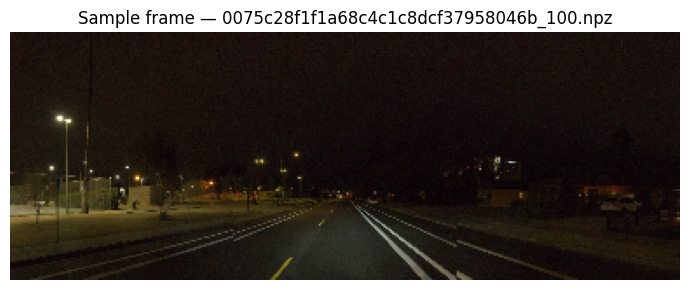

In [9]:
def load_image(fpath):
    data = np.load(fpath, allow_pickle=True)
    modality = data['_modality_data'].item()
    keys = list(modality.keys())
    img = modality[keys[0]]  # CAMERAS is always first key
    if img.dtype in [np.float32, np.float64]:
        img = np.clip(img, 0, 1)
    else:
        img = img.astype(np.uint8)
    return img

    
# Test it
img = load_image(npz_files[0])
print(f'Image shape: {img.shape}, dtype: {img.dtype}')
plt.figure(figsize=(14, 3))
plt.imshow(img)
plt.axis('off')
plt.title(f'Sample frame — {npz_files[0].name}')
plt.tight_layout()
plt.show()

## Find Class Label data

In [10]:
LABEL_JSON

WindowsPath('../data/val_sequence_name_to_scenario_cluster.json')

In [11]:
with open(LABEL_JSON) as f:
    labels = json.load(f)

In [12]:
# Peek at the JSON structure
first_key = list(labels.keys())[0]
print(f'Key: {first_key}')
print(f'Value: {labels[first_key]}')

Key: ea9000098840a70220698bd12b167f97
Value: {'scenario_cluster': 'Pedestrian'}


In [13]:
label_name, label_frame = npz_files[0].name.split('_')
label_frame = label_frame[:-4]
print(label_name)
print(label_frame)

0075c28f1f1a68c4c1c8dcf37958046b
100


In [14]:
labels[npz_files[0].name[:-8]]

{'scenario_cluster': 'Foreign Object Debris'}

## Find unique 'videos'
- split npz file name on '_'
- first item is label name
- second item is the frame name

In [15]:
# Dictionary to store each unique video/sequence and its frame numbers
seq_to_frames = {}
bad_files = []

print("total npz files:", len(npz_files))

# Find unique videos/sequences
for filepath in npz_files:
    
    # Get just the file name without the .npz extension
    filename = filepath.stem

    # Split on the underscore
    sequence_id, frame_id_text = filename.rsplit("_", 1)

    # Make sure the frame id is actually numeric
    # This skips files like: 0075..._91(1).npz
    if not frame_id_text.isdigit():
        bad_files.append(filepath)
        continue
    
    # Convert frame_id from string to integer
    frame_id = int(frame_id_text)

    # If this sequence_id has not been seen yet, create an empty list for it
    if sequence_id not in seq_to_frames:
        seq_to_frames[sequence_id] = []

    # Add the frame number to that sequence's frame list
    seq_to_frames[sequence_id].append(frame_id)

# Sort the frame IDs for each sequence
for sequence_id in seq_to_frames:
    seq_to_frames[sequence_id] = sorted(seq_to_frames[sequence_id])

print("unique videos/sequences:", len(seq_to_frames))
print("bad/skipped files:", len(bad_files))

total npz files: 106361
unique videos/sequences: 479
bad/skipped files: 1


In [16]:
seq_to_frames

{'0075c28f1f1a68c4c1c8dcf37958046b': [29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  158,
  159,
  160,
  161,
  162,
  163,
  164,
  165,
  166,
  167,
  168,
  169,
  170,
  171,
  172,
  173,
  174,
  175,
  176,

## For fun, make a gif
- frame rate is 4Hz

In [17]:
import numpy as np
import imageio.v2 as imageio
from pathlib import Path

# Relative path from your notebook folder to the gifs folder
gif_dir = Path("../data/gifs")

# Create the folder if it does not exist
gif_dir.mkdir(parents=True, exist_ok=True)

print("GIFs will be saved to:")
print(gif_dir.resolve())

GIFs will be saved to:
C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\gifs


In [18]:
# Build this once before the GIF loop
frame_lookup = {}
bad_files = []

for filepath in npz_files:
    filename = filepath.stem

    try:
        seq_id, frame_id_text = filename.rsplit("_", 1)
    except ValueError:
        bad_files.append(filepath)
        continue

    # Skip duplicate/malformed files like ..._91(1).npz
    if not frame_id_text.isdigit():
        bad_files.append(filepath)
        continue

    frame_id = int(frame_id_text)
    frame_lookup[(seq_id, frame_id)] = filepath

print("valid files:", len(frame_lookup))
print("bad files skipped:", len(bad_files))

valid files: 106360
bad files skipped: 1


In [19]:
gif_count = 1
missing_count = 0

for sequence_id, frame_ids in seq_to_frames.items():

    print(f"Creating gif {gif_count} of {len(seq_to_frames)}")

    frames_for_gif = []

    for frame_id in sorted(frame_ids):

        key = (sequence_id, frame_id)

        if key not in frame_lookup:
            print(f"  Missing frame {frame_id} for sequence {sequence_id}")
            missing_count += 1
            continue

        fpath = frame_lookup[key]
        img = load_image(fpath)

        # Convert image to uint8 for GIF writing
        if img.dtype != np.uint8:
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

        frames_for_gif.append(img)

    if len(frames_for_gif) == 0:
        print(f"  No frames found for {sequence_id}, skipping.")
        gif_count += 1
        continue

    # Save using relative path
    gif_path = gif_dir / f"{sequence_id}.gif"

    imageio.mimsave(gif_path, frames_for_gif, duration=0.15)

    print(f"  Saved to: {gif_path}")

    gif_count += 1

print("Done.")
print("Missing frames:", missing_count)
print("Bad files skipped:", len(bad_files))

Creating gif 1 of 479
  Saved to: ..\data\gifs\0075c28f1f1a68c4c1c8dcf37958046b.gif
Creating gif 2 of 479
  Saved to: ..\data\gifs\0081c482170156ee7aedf36157d4ff21.gif
Creating gif 3 of 479
  Saved to: ..\data\gifs\00c73f2a3515da4249d4416a544c09b2.gif
Creating gif 4 of 479
  Saved to: ..\data\gifs\00f755ca895493997db24f66b4ea7e24.gif
Creating gif 5 of 479
  Saved to: ..\data\gifs\01d758be9706c2534b80c2dd3a4234b9.gif
Creating gif 6 of 479
  Saved to: ..\data\gifs\023de465f73acb957c34bdf9299ed39b.gif
Creating gif 7 of 479
  Saved to: ..\data\gifs\02a549944c0a5338903c22adb57b0501.gif
Creating gif 8 of 479
  Saved to: ..\data\gifs\0414d4f697ebf7301d2ddfc1e578a6d9.gif
Creating gif 9 of 479
  Saved to: ..\data\gifs\0426ef72af3ce42152d3559ee3bf2b9b.gif
Creating gif 10 of 479
  Saved to: ..\data\gifs\0441374eb46e1d94536cf7fce1237e9f.gif
Creating gif 11 of 479
  Saved to: ..\data\gifs\04b1507c7b4a33855b6f09a5b0050e70.gif
Creating gif 12 of 479
  Saved to: ..\data\gifs\04b162cce96ccaebd5e4ed92c6